In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib as mpl

import cell2location

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator.

In [2]:
# prepare my GPU
import os
gpu_list = [5]
gpu_list_str = ','.join(map(str, gpu_list))
os.environ.setdefault("CUDA_VISIBLE_DEVICES", gpu_list_str)

'5'

In [3]:
# Read data
adata_ref = sc.read(f'/data1/r20user3/shared_project/Hist2Cell/data/breast_sc/breast_sc_atlas.h5ad')
adata_ref = adata_ref.raw.to_adata()

In [4]:
adata_ref.var['SYMBOL'] = adata_ref.var.index 

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


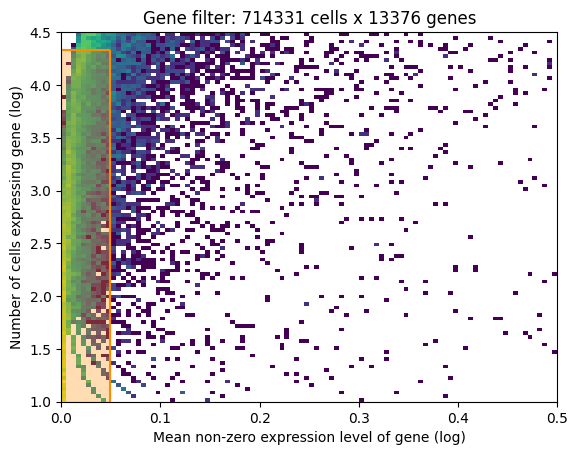

In [5]:
from cell2location.utils.filtering import filter_genes
selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

# filter the object
adata_ref = adata_ref[:, selected].copy()

In [ ]:
# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(adata=adata_ref, 
                        # 10X reaction / sample / batch
                        batch_key='sample_id', 
                        # cell type, covariate used for constructing signatures
                        labels_key='cell_type', 
                        # multiplicative technical effects (platform, 3' vs 5', donor effect)
                        categorical_covariate_keys=['donor_id']
                       )

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [ ]:
# create the regression model
from cell2location.models import RegressionModel
mod = RegressionModel(adata_ref) 

# view anndata_setup as a sanity check
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.0.4.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample_id',
│   'labels_key': 'cell_type',
│   'categorical_covariate_keys': ['donor_id'],
│   'continuous_covariate_keys': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │  167   │
│         n_cells          │ 714331 │
│ n_extra_categorical_covs │   1    │
│ n_extra_continuous_covs  │   0    │
│         n_labels         │   39   │
│          n_vars          │ 13376  │
└──────────────────────────┴────────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│         ind_x          │           adata.obs['_indices']            │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

                    batch State Registry                     
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample_id'] │  hbca_c01  │          0          │
│                        │  hbca_c02  │          1          │
│                        │  hbca_c03  │          2          │
│                        │  hbca_c04  │          3          │
│                        │  hbca_c05  │          4          │
│                        │  hbca_c06  │          5          │
│                        │  hbca_c07  │          6          │
│                        │  hbca_c08  │          7          │
│                        │  hbca_c09  │          8          │
│                        │  hbca_c10  │          9          │
│                        │  hbca_c11  │         10          │
│                        │  hbca_c12  │         11          │
│                        │  hbca_c13  │         12          │
│                        │  hbca_c14  │         13          │
│                        │  hbca_c15  │         14          │
│                        │  hbca_c16  │         15          │
│                        │  hbca_c17  │         16          │
│                        │  hbca_c18  │         17          │
│                        │  hbca_c19  │         18          │
│                        │  hbca_c20  │         19          │
│                        │  hbca_c21  │         20          │
│                        │  hbca_c22  │         21          │
│                        │  hbca_c23  │         22          │
│                        │  hbca_c24  │         23          │
│                        │  hbca_c25  │         24          │
│                        │  hbca_c26  │         25          │
│                        │  hbca_c27  │         26          │
│                        │  hbca_c28  │         27          │
│                        │  hbca_c29  │         28          │
│                        │  hbca_c30  │         29          │
│                        │  hbca_c31  │         30          │
│                        │  hbca_c32  │         31          │
│                        │  hbca_c33  │         32          │
│                        │  hbca_c34  │         33          │
│                        │  hbca_c35  │         34          │
│                        │  hbca_c36  │         35          │
│                        │  hbca_c37  │         36          │
│                        │  hbca_c38  │         37          │
│                        │  hbca_c39  │         38          │
│                        │  hbca_c40  │         39          │
│                        │  hbca_c41  │         40          │
│                        │  hbca_c42  │         41          │
│                        │  hbca_c43  │         42          │
│                        │  hbca_c44  │         43          │
│                        │  hbca_c45  │         44          │
│                        │  hbca_c46  │         45          │
│                        │  hbca_c47  │         46          │
│                        │  hbca_c48  │         47          │
│                        │  hbca_c49  │         48          │
│                        │  hbca_c50  │         49          │
│                        │  hbca_c51  │         50          │
│                        │  hbca_c52  │         51          │
│                        │  hbca_c53  │         52          │
│                        │  hbca_c54  │         53          │
│                        │  hbca_c55  │         54          │
│                        │  hbca_c56  │         55          │
│                        │  hbca_c57  │         56          │
│                        │  hbca_c58  │         57          │
│                        │  hbca_c59  │         58          │
│                        │  hbca_c60  │         59          │
│                        │  hbca

                                      labels State Registry                                       
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃                   Categories                    ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['cell_type'] │                   fibroblast                    │          0          │
│                        │                     T cell                      │          1          │
│                        │                    mast cell                    │          2          │
│                        │                   macrophage                    │          3          │
│                        │     vascular associated smooth muscle cell      │          4          │
│                        │           CD4-positive helper T cell            │          5          │
│                        │                   lymphocyte                    │          6          │
│                        │               natural killer cell               │          7          │
│                        │         CD4-positive, alpha-beta T cell         │          8          │
│                        │                   basal cell                    │          9          │
│                        │                    pericyte                     │         10          │
│                        │                  myeloid cell                   │         11          │
│                        │                   neutrophil                    │         12          │
│                        │             myeloid dendritic cell              │         13          │
│                        │           plasmacytoid dendritic cell           │         14          │
│                        │                  naive B cell                   │         15          │
│                        │               gamma-delta T cell                │         16          │
│                        │                mature NK T cell                 │         17          │
│                        │                regulatory T cell                │         18          │
│                        │               classical monocyte                │         19          │
│                        │             inflammatory macrophage             │         20          │
│                        │             non-classical monocyte              │         21          │
│                        │       alternatively activated macrophage        │         22          │
│                        │    activated CD4-positive, alpha-beta T cell    │         23          │
│                        │ effector memory CD4-positive, alpha-beta T cell │         24          │
│                        │    activated CD8-positive, alpha-beta T cell    │         25          │
│                        │     CD8-positive, alpha-beta memory T cell      │         26          │
│                        │ effector memory CD8-positive, alpha-beta T cell │         27          │
│                        │            unswitched memory B cell             │         28          │
│                        │          class switched memory B cell           │         29          │
│                        │                 IgG plasma cell                 │         30          │
│                        │                 IgA plasma cell                 │         31          │
│                        │           conventional dendritic cell           │         32          │
│                        │      endothelial cell of lymphatic vessel       │         33          │
│                        │           capillary endothelial cell            │         34          │
│                        │    luminal epithelial cell of mammary gland     │         35          │
│                        │          mamm

           extra_categorical_covs State Registry            
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['donor_id'] │    P01     │          0          │
│                       │    P02     │          1          │
│                       │    P03     │          2          │
│                       │    P04     │          3          │
│                       │    P05     │          4          │
│                       │    P06     │          5          │
│                       │    P07     │          6          │
│                       │    P08     │          7          │
│                       │    P09     │          8          │
│                       │    P10     │          9          │
│                       │    P11     │         10          │
│                       │    P12     │         11          │
│                       │    P13     │         12          │
│                       │    P14     │         13          │
│                       │    P15     │         14          │
│                       │    P16     │         15          │
│                       │    P17     │         16          │
│                       │    P18     │         17          │
│                       │    P19     │         18          │
│                       │    P20     │         19          │
│                       │    P21     │         20          │
│                       │    P22     │         21          │
│                       │    P23     │         22          │
│                       │    P24     │         23          │
│                       │    P25     │         24          │
│                       │    P26     │         25          │
│                       │    P27     │         26          │
│                       │    P28     │         27          │
│                       │    P29     │         28          │
│                       │    P30     │         29          │
│                       │    P31     │         30          │
│                       │    P32     │         31          │
│                       │    P33     │         32          │
│                       │    P34     │         33          │
│                       │    P35     │         34          │
│                       │    P36     │         35          │
│                       │    P37     │         36          │
│                       │    P38     │         37          │
│                       │    P39     │         38          │
│                       │    P40     │         39          │
│                       │    P41     │         40          │
│                       │    P42     │         41          │
│                       │    P43     │         42          │
│                       │    P44     │         43          │
│                       │    P45     │         44          │
│                       │    P46     │         45          │
│                       │    P47     │         46          │
│                       │    P48     │         47          │
│                       │    P49     │         48          │
│                       │    P50     │         49          │
│                       │    P51     │         50          │
│                       │    P52     │         51          │
│                       │    P53     │         52          │
│                       │    P54     │         53          │
│                       │    P55     │         54          │
│                       │    P56     │         55          │
│                       │    P57     │         56          │
│                       │    P58     │         57          │
│                       │    P59     │         58          │
│                       │    P60     │         59          │
│                       │    P61     │         60          │
│                       │    P62   

In [ ]:
# mod.train(max_epochs=500, use_gpu=True, batch_size=20000)
mod.train(max_epochs=500, use_gpu=True, batch_size=20000)

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scvi/train/_trainrunner.py:76: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
L

Epoch 500/500: 100%|██████████| 500/500 [6:32:07<00:00, 44.81s/it, v_num=1, elbo_train=4.28e+9]  

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 500/500: 100%|██████████| 500/500 [6:32:07<00:00, 47.05s/it, v_num=1, elbo_train=4.28e+9]


In [ ]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_ref = mod.export_posterior(
    adata_ref, sample_kwargs={'num_samples': 1000, 'batch_size': 2500, 'use_gpu': True}
)

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scvi/model/base/_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


Sampling global variables, sample: 100%|██████████| 999/999 [00:26<00:00, 37.49it/s]


In [ ]:
results_folder = '/data1/r20user3/shared_project/Hist2Cell/data/breast_sc/cell2location_res'
ref_run_name = f'{results_folder}/breast_reference_signatures'

# Save model
mod.save(f"{ref_run_name}", overwrite=True)

# Save anndata object with results
adata_file = f"{ref_run_name}/breast_sc.h5ad"
adata_ref.write(adata_file)

In [1]:
import scanpy as sc
import numpy as np
import cell2location


results_folder = '/data1/r20user3/shared_project/Hist2Cell/data/breast_sc/cell2location_res'
ref_run_name = f'{results_folder}/breast_reference_signatures'

adata_file = f"{ref_run_name}/breast_sc.h5ad"

adata_ref = sc.read_h5ad(adata_file)
mod = cell2location.models.RegressionModel.load(f"{ref_run_name}", adata_ref)
adata_ref

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator.

INFO     File                                                                                                      
         /data1/r20user3/shared_project/Hist2Cell/data/breast_sc/cell2location_res/breast_reference_signatures/mode
         l.pt already downloaded                                                                                   


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 1/28:   4%|▎         | 1/28 [00:00<00:07,  3.71it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/28:   4%|▎         | 1/28 [00:00<00:07,  3.50it/s, v_num=1]


AnnData object with n_obs × n_vars = 714331 × 13376
    obs: 'mapped_reference_assembly', 'mapped_reference_annotation', 'alignment_software', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'donor_living_at_sample_collection', 'donor_menopausal_status', 'organism_ontology_term_id', 'sample_uuid', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_derivation_process', 'sample_source', 'donor_BMI_at_collection', 'suspension_depleted_cell_types', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_dissociation_time', 'suspension_percent_cell_viability', 'suspension_uuid', 'suspension_type', 'library_uuid', 'assay_ontology_term_id', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'cell_state', 'disease_ontology_term_id', 'sex_ontology_term_id', 'n_count_rna', 'n_feature_rna', 'percent_mito', 'percent_rb', 'tissue_location', 'bmi_group', 'procedure_group', 'ag

In [2]:
adata_ref = mod.export_posterior(
    adata_ref, use_quantiles=True,
    add_to_varm=["q05","q50", "q95", "q0001"],
    sample_kwargs={'batch_size': 1000, 'use_gpu': False}
)

In [3]:
results_folder = '/data1/r20user3/shared_project/Hist2Cell/data/breast_sc/cell2location_res'
ref_run_name = f'{results_folder}/breast_reference_signatures'

# Save model
mod.save(f"{ref_run_name}", overwrite=True)

# Save anndata object with results
adata_file = f"{ref_run_name}/breast_sc.h5ad"
adata_ref.write(adata_file)

In [4]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}' 
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}' 
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.head()

,fibroblast,T cell,mast cell,macrophage,vascular associated smooth muscle cell,CD4-positive helper T cell,lymphocyte,natural killer cell,"CD4-positive, alpha-beta T cell",basal cell,...,class switched memory B cell,IgG plasma cell,IgA plasma cell,conventional dendritic cell,endothelial cell of lymphatic vessel,capillary endothelial cell,luminal epithelial cell of mammary gland,mammary gland epithelial cell,vein endothelial cell,endothelial cell of artery
ENSG00000187634,0.016341,0.003520,0.000729,0.000525,0.000805,0.000034,0.001233,0.000295,0.000218,0.000394,...,0.000222,0.006724,0.004025,0.000890,0.000852,0.001395,0.004111,0.000428,0.000224,0.000118
ENSG00000188976,0.117370,0.146280,0.016717,0.073333,0.051991,0.039917,0.051192,0.049764,0.043392,0.171738,...,0.042114,0.026784,0.040397,0.065859,0.053536,0.109784,0.256512,0.276506,0.165131,0.051012
ENSG00000187583,0.000311,0.005345,0.000754,0.003718,0.000774,0.003845,0.008622,0.000531,0.001245,0.003728,...,0.000648,0.021841,0.023673,0.004289,0.000818,0.000226,0.051024,0.063262,0.000308,0.000094
ENSG00000188290,0.102318,0.060894,0.029283,0.107470,1.194010,0.007908,0.039131,0.012359,0.001107,0.012373,...,0.003083,0.004363,0.005516,0.153251,0.294717,0.089528,0.950763,0.654805,0.069212,0.339997
ENSG00000187608,0.148548,0.641984,0.027741,2.256322,0.478522,0.162423,0.235466,0.186748,0.154152,0.004705,...,0.052665,0.103493,0.156098,0.438484,0.182963,0.565770,0.097423,0.059964,0.560094,0.859192


In [5]:
inf_aver.to_csv(f"{ref_run_name}/inf_aver.csv")

In [6]:
import scanpy as sc
import numpy as np
import anndata as ad
from scipy.sparse import csr_matrix
import glob
import pandas as pd
import os
# prepare my GPU
gpu_list = [4]
gpu_list_str = ','.join(map(str, gpu_list))
os.environ.setdefault("CUDA_VISIBLE_DEVICES", gpu_list_str)


def get_anndata_her2st(sample):
    img_path = os.path.join(sample, [f for f in os.listdir(sample) if f.endswith('.jpg') and f != 'spot_view.jpg'][0])
    
    spots_coord = pd.read_csv(os.path.join(sample, "spots.csv"), index_col=0)
    cnt = pd.read_csv(os.path.join(sample, "stdata.csv"), index_col=0)
    
    spots_coord = spots_coord.loc[cnt.index]

    location = np.matrix(spots_coord.values)
    Xdense = np.matrix(cnt.values)
    
    batch = np.array([sample.split('/')[-1] for i in range(Xdense.shape[0])])

    X = csr_matrix(Xdense, dtype=np.float32)
    adata_vis = ad.AnnData(X, obsm={"spatial": location}, obs={"sample": batch})
    adata_vis.obs_names = [sample.split('/')[-1] + '_' + idx for idx in list(spots_coord.index)]
    # adata_vis.obs_names = list(spots_coord.index)
    adata_vis.var_names = list(cnt.columns)
    return adata_vis

samples_path = [path for path in glob.glob("/data1/r20user3/shared_project/Hist2Cell/data/her2st/*") if not path.endswith(".h5ad") or not path.endswith(".ipynb")]

adata_list = []
from tqdm import tqdm
for i in tqdm(range(0, len(samples_path))):
    adata_1 = get_anndata_her2st(samples_path[i])
    adata_list.append(adata_1)

adata_vis = ad.concat(adata_list)
adata_vis

100%|██████████| 36/36 [00:26<00:00,  1.34it/s]
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/anndata/_core/merge.py:217: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(dtype):


AnnData object with n_obs × n_vars = 13620 × 11871
    obs: 'sample'
    obsm: 'spatial'

In [7]:
gene_name_df = pd.DataFrame(data=adata_ref.var['feature_name'].index, index=adata_ref.var['feature_name'])
gene_name_df

,0
feature_name,
SAMD11,ENSG00000187634
NOC2L,ENSG00000188976
PLEKHN1,ENSG00000187583
HES4,ENSG00000188290
ISG15,ENSG00000187608
...,...
MT-ND6,ENSG00000198695
MT-CYB,ENSG00000198727
ENSG00000277836.1,ENSG00000277836


In [8]:
# find shared genes and subset both anndata and reference signatures
intersect = np.intersect1d(adata_vis.var_names, adata_ref.var['feature_name'])

adata_vis = adata_vis[:, intersect].copy()
gene_id = gene_name_df.loc[adata_vis.var_names]
adata_vis.var_names = gene_id[0]
inf_aver = inf_aver.loc[adata_vis.var_names, :].copy()

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [9]:
import cell2location

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_vis, batch_key="sample")

In [10]:
# create and train the model
mod = cell2location.models.Cell2location(
    adata_vis, cell_state_df=inf_aver, 
    # the expected average cell abundance: tissue-dependent 
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=30,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=20
) 
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.0.4.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  36   │
│         n_cells          │ 13620 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 9739  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                   batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │     A1     │          0          │
│                     │     A2     │          1          │
│                     │     A3     │          2          │
│                     │     A4     │          3          │
│                     │     A5     │          4          │
│                     │     A6     │          5          │
│                     │     B1     │          6          │
│                     │     B2     │          7          │
│                     │     B3     │          8          │
│                     │     B4     │          9          │
│                     │     B5     │         10          │
│                     │     B6     │         11          │
│                     │     C1     │         12          │
│                     │     C2     │         13          │
│                     │     C3     │         14          │
│                     │     C4     │         15          │
│                     │     C5     │         16          │
│                     │     C6     │         17          │
│                     │     D1     │         18          │
│                     │     D2     │         19          │
│                     │     D3     │         20          │
│                     │     D4     │         21          │
│                     │     D5     │         22          │
│                     │     D6     │         23          │
│                     │     E1     │         24          │
│                     │     E2     │         25          │
│                     │     E3     │         26          │
│                     │     F1     │         27          │
│                     │     F2     │         28          │
│                     │     F3     │         29          │
│                     │     G1     │         30          │
│                     │     G2     │         31          │
│                     │     G3     │         32          │
│                     │     H1     │         33          │
│                     │     H2     │         34          │
│                     │     H3     │         35          │
└─────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scvi/train/_trainrunner.py:76: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [4]
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:281: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 40000/40000: 100%|██████████| 40000/40000 [1:41:56<00:00,  6.56it/s, v_num=1, elbo_train=7.17e+7]  

`Trainer.fit` stopped: `max_epochs=40000` reached.


Epoch 40000/40000: 100%|██████████| 40000/40000 [1:41:56<00:00,  6.54it/s, v_num=1, elbo_train=7.17e+7]


NameError: name 'plt' is not defined

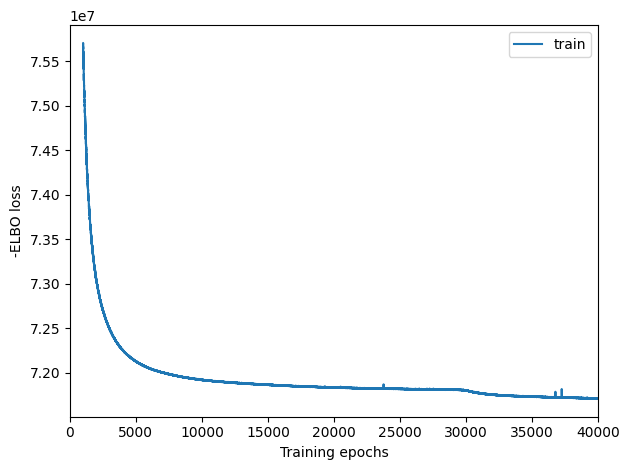

In [11]:
mod.train(max_epochs=40000,  
          # train using full data (batch_size=None)
          batch_size=None, 
          # use all data points in training because 
          # we need to estimate cell abundance at all locations
          train_size=1,
          use_gpu=True,
         )

# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(1000)
plt.legend(labels=['full data training'])

In [13]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_vis = mod.export_posterior(
    adata_vis, sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs, 'use_gpu': True}
)

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scvi/model/base/_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


Sampling global variables, sample: 100%|██████████| 999/999 [00:24<00:00, 41.31it/s]


In [14]:
adata_vis.obsm['q05_cell_abundance_w_sf']

,q05cell_abundance_w_sf_fibroblast,q05cell_abundance_w_sf_T cell,q05cell_abundance_w_sf_mast cell,q05cell_abundance_w_sf_macrophage,q05cell_abundance_w_sf_vascular associated smooth muscle cell,q05cell_abundance_w_sf_CD4-positive helper T cell,q05cell_abundance_w_sf_lymphocyte,q05cell_abundance_w_sf_natural killer cell,"q05cell_abundance_w_sf_CD4-positive, alpha-beta T cell",q05cell_abundance_w_sf_basal cell,...,q05cell_abundance_w_sf_class switched memory B cell,q05cell_abundance_w_sf_IgG plasma cell,q05cell_abundance_w_sf_IgA plasma cell,q05cell_abundance_w_sf_conventional dendritic cell,q05cell_abundance_w_sf_endothelial cell of lymphatic vessel,q05cell_abundance_w_sf_capillary endothelial cell,q05cell_abundance_w_sf_luminal epithelial cell of mammary gland,q05cell_abundance_w_sf_mammary gland epithelial cell,q05cell_abundance_w_sf_vein endothelial cell,q05cell_abundance_w_sf_endothelial cell of artery
B4_10x14,0.267667,0.002623,0.021193,0.020354,0.377587,0.027249,0.009006,0.025433,0.085316,0.350888,...,0.035001,0.002019,0.278451,0.009713,0.042078,0.011010,1.415073,0.488554,0.007146,0.018299
B4_10x15,0.087630,0.001081,0.004196,0.110913,0.036976,0.007117,0.003539,0.006057,0.041642,0.009102,...,0.017286,0.000494,0.109303,0.002226,0.007236,0.001798,0.886871,0.012190,0.001559,0.003590
B4_10x16,0.292244,0.000260,0.028161,0.024138,0.109216,0.023419,0.012287,0.020887,0.100650,0.125468,...,0.043821,0.006469,0.052168,0.035185,0.079167,0.006490,0.966146,0.112398,0.002656,0.009829
B4_10x17,0.395908,0.001552,0.022174,0.022269,0.190207,0.019238,0.006866,0.006473,0.047833,0.125526,...,0.026758,0.002321,0.061429,0.012849,0.032552,0.033573,2.399666,0.256824,0.012047,0.036338
B4_10x18,1.354429,0.017493,0.177652,0.159549,1.104664,0.152727,0.062826,0.095392,0.328677,1.076221,...,0.184328,0.058043,0.554858,0.179550,0.226728,0.110762,5.503827,3.959423,0.088870,0.155928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2_9x26,0.104482,1.712897,0.975251,0.090959,0.066424,0.468661,0.441269,0.108055,0.386282,0.801757,...,0.168089,0.018642,0.000178,0.014107,0.129679,0.050688,75.516436,0.097126,0.018837,0.338173
A2_9x27,0.669830,0.186966,0.180695,0.111774,0.388735,0.075580,0.045929,0.012690,0.052652,0.517690,...,0.032361,0.008949,0.003123,0.010370,0.082738,0.026364,18.200869,0.272354,0.003979,0.068936
A2_9x28,1.356699,2.151082,1.285758,0.379468,0.474862,0.655397,0.559862,0.169171,0.501134,1.392382,...,0.287488,0.103163,0.013120,0.105399,0.326845,0.106250,84.555565,0.513238,0.031168,0.542639
A2_9x29,0.748918,1.210857,0.791511,0.871246,0.529231,0.625092,0.382477,0.253231,0.980976,1.083941,...,0.443715,0.096043,0.020901,0.232332,0.395918,0.140691,49.920857,0.385784,0.124075,0.763860


In [15]:
run_name = f'{results_folder}/her2st'

# Save model
mod.save(f"{run_name}", overwrite=True)

In [16]:
# Save anndata object with results
adata_file = f"{run_name}/sp.h5ad"
adata_vis.write(adata_file)
adata_file

'/data1/r20user3/shared_project/Hist2Cell/data/breast_sc/cell2location_res/her2st/sp.h5ad'